In [236]:
import os, glob, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from matplotlib import style
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [913]:
chart_panel_df = pd.read_csv('combined_panel_chart_data.csv', index_col=0)
chart_panel_df.sort_values(['Country', 'Year'])
chart_panel_df.to_csv('combined_panel_chart_data.csv')

In [728]:
chart_panel_df.dtypes

Country                object
Treat_Grp               int64
Year                    int64
post_recession          int64
BPM                   float64
Danceability          float64
Energy                float64
Happy                 float64
Loudness              float64
youth_unemployment    float64
dtype: object

To find the weights, we run an inverted regression to fit the pre-recession years to post recession. I'm just following the guy at 

https://matheusfacure.github.io/python-causality-handbook/15-Synthetic-Control.html

In [971]:
features = ['Energy', 'youth_unemployment']

inverted = (chart_panel_df[chart_panel_df['Year'] < 2009] # filter pre-intervention period
            .pivot(index='Country', columns="Year")[features] # make one column per year and one row per state
            .T) # flip the table to have one column per state

inverted.head()

Country           AUS       BRA       KOR       SGP      USA
       Year                                                 
Energy 2000  0.804520  0.712549  0.678406  0.729938  0.70636
       2001  0.763293  0.686278  0.638587  0.698960  0.69638
       2002  0.765958  0.717773  0.624278  0.747966  0.70391
       2003  0.729938  0.707238  0.613327  0.716280  0.67967
       2004  0.712433  0.683562  0.619160  0.711340  0.67874

In [972]:
inverted.dtypes

Country
AUS    float64
BRA    float64
KOR    float64
SGP    float64
USA    float64
dtype: object

In [975]:
y = inverted['USA'].values 
X = inverted.drop('USA', axis=1).values  

In [976]:
from sklearn.linear_model import LinearRegression
weights_lr = LinearRegression(fit_intercept=False).fit(X, y).coef_
weights_lr.round(3)

array([0.089, 0.18 , 0.185, 0.53 ])

In [977]:
us_synth_nw = (chart_panel_df[chart_panel_df['Country'] != "USA"] 
                .pivot(index='Year', columns="Country")["Energy"]
                .values.dot(weights_lr))
us_synth_nw

array([0.71225515, 0.68007076, 0.70929934, 0.68537306, 0.67801082,
       0.68831765, 0.68081991, 0.70594655, 0.71665576, 0.73541528,
       0.75391001, 0.75033931, 0.74545221, 0.71148568])

In [978]:
US_df = chart_panel_df[chart_panel_df['Country'] == "USA"].sort_values('Year')
actual_energy = US_df['Energy'].to_numpy()
actual_energy

array([0.70636   , 0.69638   , 0.70391   , 0.67967   , 0.67874   ,
       0.68062   , 0.68216   , 0.71572   , 0.71223   , 0.72959   ,
       0.75199   , 0.75441   , 0.73787879, 0.70602   ])

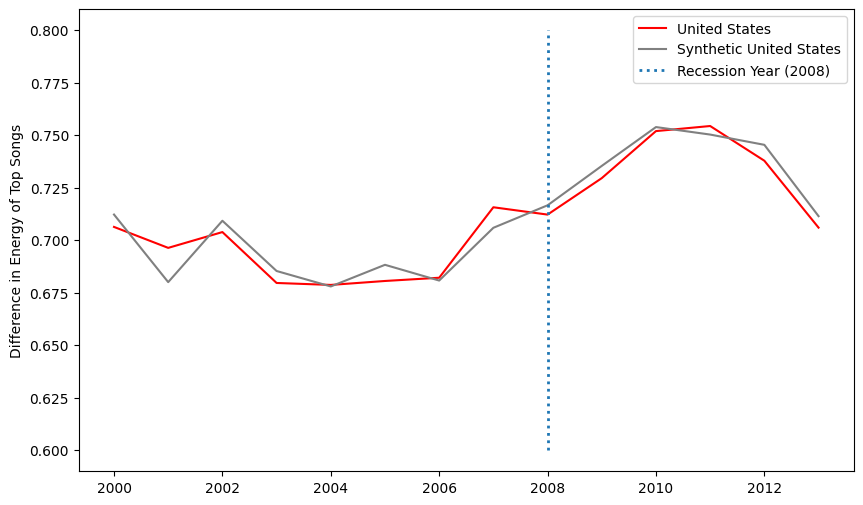

In [979]:
# SC without weight optimization
plt.figure(figsize=(10,6))
years = np.array(list(range(2000, 2014)))
plt.plot(years, actual_energy, color='red', label="United States")
plt.plot(years, us_synth_nw, color='gray', label="Synthetic United States")
plt.vlines(x=2008, ymin=0.6, ymax=0.8, linestyle=":", lw=2, label="Recession Year (2008)")
plt.ylabel("Difference in Energy of Top Songs")
plt.legend()

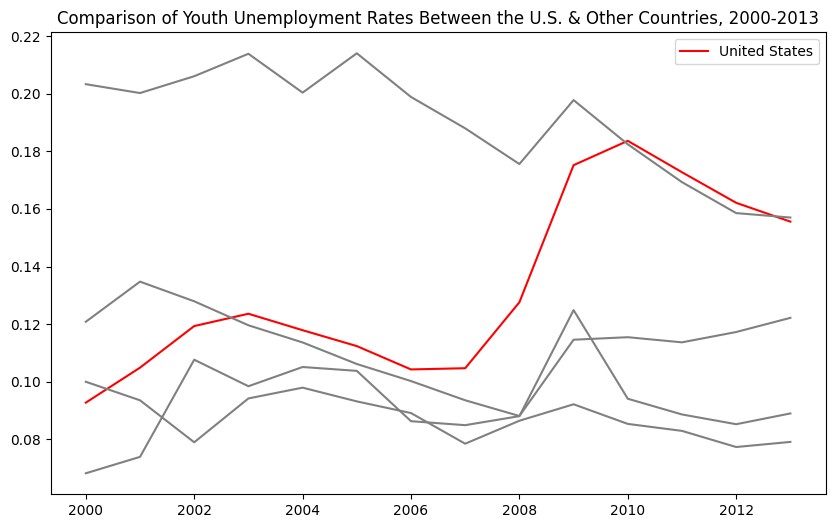

In [902]:
US_df = chart_panel_df[chart_panel_df['Country'] == "USA"].sort_values('Year')
yu_us = US_df['youth_unemployment'].to_numpy()

plt.figure(figsize=(10,6))
plt.plot(years, yu_us, color="red", label="United States")

other_countries = countries = ['KOR', 'BRA', 'SGP', 'AUS']
for country in other_countries:
    other_df = chart_panel_df[chart_panel_df['Country'] == country].sort_values('Year')
    other_energy = other_df['youth_unemployment'].to_numpy()
    plt.plot(years, other_energy, color="gray")

plt.title(label="Comparison of Youth Unemployment Rates Between the U.S. & Other Countries, 2000-2013")   
plt.legend()

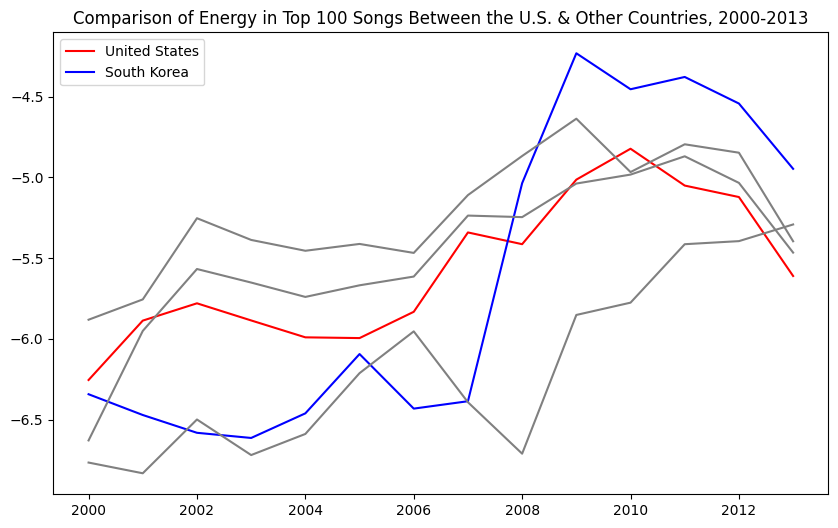

In [949]:
US_df = chart_panel_df[chart_panel_df['Country'] == "USA"].sort_values('Year')
energy_us = US_df['Loudness'].to_numpy()

plt.figure(figsize=(10,6))
plt.plot(years, energy_us, color="red", label="United States")

other_countries = countries = ['KOR', 'BRA', 'SGP', 'AUS']
for country in other_countries:
    other_df = chart_panel_df[chart_panel_df['Country'] == country].sort_values('Year')
    other_energy = other_df['Loudness'].to_numpy()
    if country == 'KOR':
        plt.plot(years, other_energy, color="blue", label="South Korea")
    else:
        plt.plot(years, other_energy, color="gray")

plt.title(label="Comparison of Energy in Top 100 Songs Between the U.S. & Other Countries, 2000-2013")   
plt.legend()

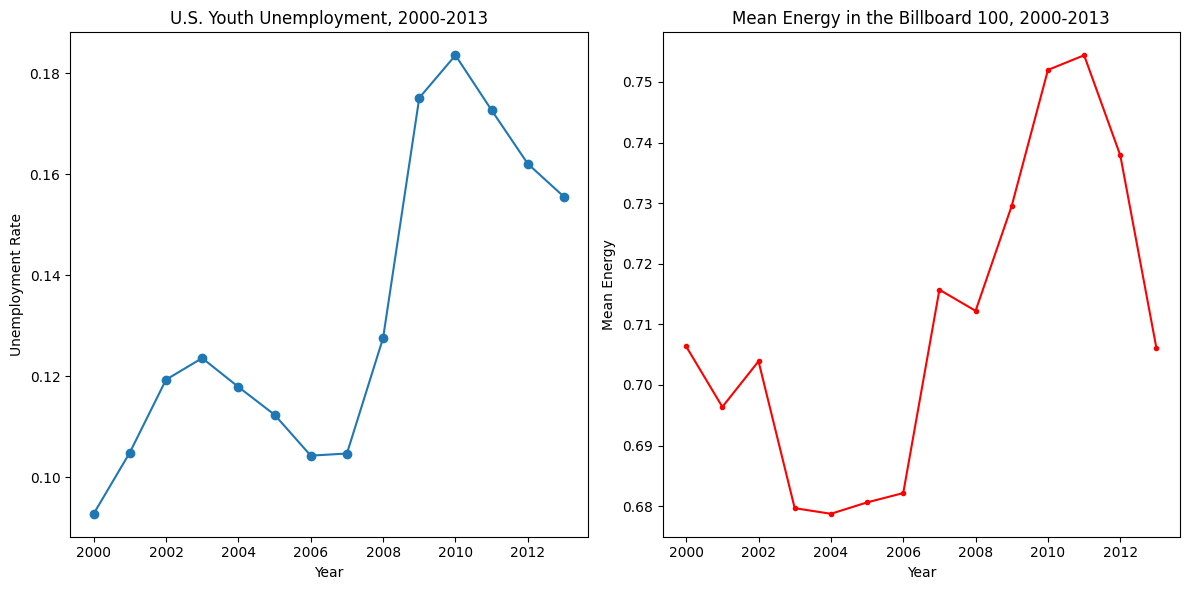

In [847]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

ax[0].plot(years, yu_us, 'o-')
ax[0].set_title('U.S. Youth Unemployment, 2000-2013')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Unemployment Rate')

ax[1].plot(years, energy_us, '.-', color='red')
ax[1].set_title('Mean Energy in the Billboard 100, 2000-2013')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Mean Energy')

plt.tight_layout() 
plt.show()

In [963]:
from typing import List
from operator import add
from toolz import reduce, partial
from scipy.optimize import fmin_slsqp


def loss_w(W, X, y) -> float:
    return np.sqrt(np.mean((y - X.dot(W))**2))

def get_w(X, y):
    
    w_start = [1/X.shape[1]]*X.shape[1]

    weights = fmin_slsqp(partial(loss_w, X=X, y=y),
                        np.array(w_start),
                        f_eqcons=lambda x: np.sum(x) - 1,
                        bounds=[(0.0, 1.0)]*len(w_start),
                        disp=False)
    return weights

In [951]:
def synthetic_control(year: int, outcome_feature: str, chart_panel_df: pd.DataFrame) -> np.array:
    
    features = ['Energy', 'youth_unemployment']

    inverted = (chart_panel_df[chart_panel_df['Year'] < year] # filter pre-intervention period
                .pivot(index='Country', columns="Year")[features] # make one column per year and one row per state
                .T) # flip the table to have one column per state
    
    y_w = inverted["USA"].values # treated
    x_w = inverted.drop('USA', axis=1)
    weights = get_w(x_w, y_w)
    
    synthetic = (chart_panel_df[chart_panel_df['Country'] != "USA"] 
                .pivot(index='Year', columns="Country")[outcome_feature]
                .values.dot(weights))
    
    US_df = chart_panel_df[chart_panel_df['Country'] == "USA"].sort_values('Year')
    actual_energy = US_df[outcome_feature].to_numpy()

    plt.figure(figsize=(12,6))
    years = np.array(list(range(2000, 2014)))
    # plt.plot(years, actual_energy, color='red', label="United States")
    # plt.plot(years, synthetic, color='gray', label="Synthetic United States")
    # plt.vlines(x=year, ymin=0.65, ymax=0.8, linestyle=":", lw=2, label="Recession Year")
    # plt.ylabel("Difference in Energy of Top Songs")
    # plt.legend()
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    
    ax[0].plot(years, actual_energy, color='red', label="United States")
    ax[0].plot(years, synthetic, color='gray', label="Synthetic United States")
    ax[0].vlines(x=year, ymin=0.65, ymax=0.8, linestyle=":", lw=2, label="Recession Year")
    ax[0].set_title('Difference in Energy of Top Songs')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Energy')

    ax[1].plot(years, actual_energy - synthetic, color='red')
    ax[1].vlines(x=year, ymin=-0.1, ymax=0.1, linestyle=":", lw=2, label="Recession Year")
    ax[1].hlines(y=0, xmin=2000, xmax=2013, lw=2, color='gray')
    ax[1].set_title('Synthetic Across Time, 2000-2013')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Energy')
    
    plt.show()
    
    return weights
    

<Figure size 1200x600 with 0 Axes>

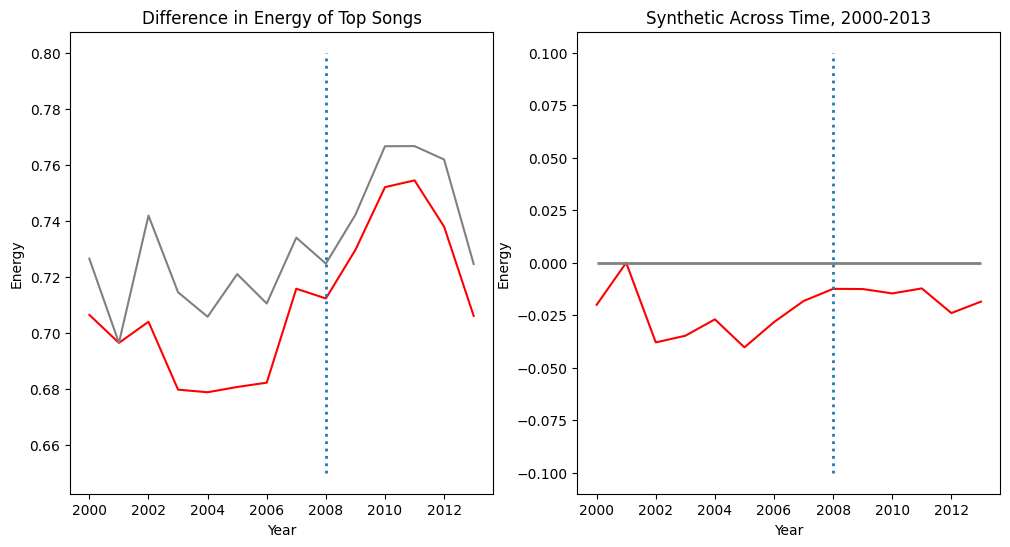

[1.02157393e-16 2.02854697e-01 7.97145303e-01]


In [964]:
# leave-one-out check: South Korea
chart_panel_df_no_kor = chart_panel_df[chart_panel_df['Country'] != "KOR"]
print(synthetic_control(2008, 'Energy', chart_panel_df_no_kor))

<Figure size 1200x600 with 0 Axes>

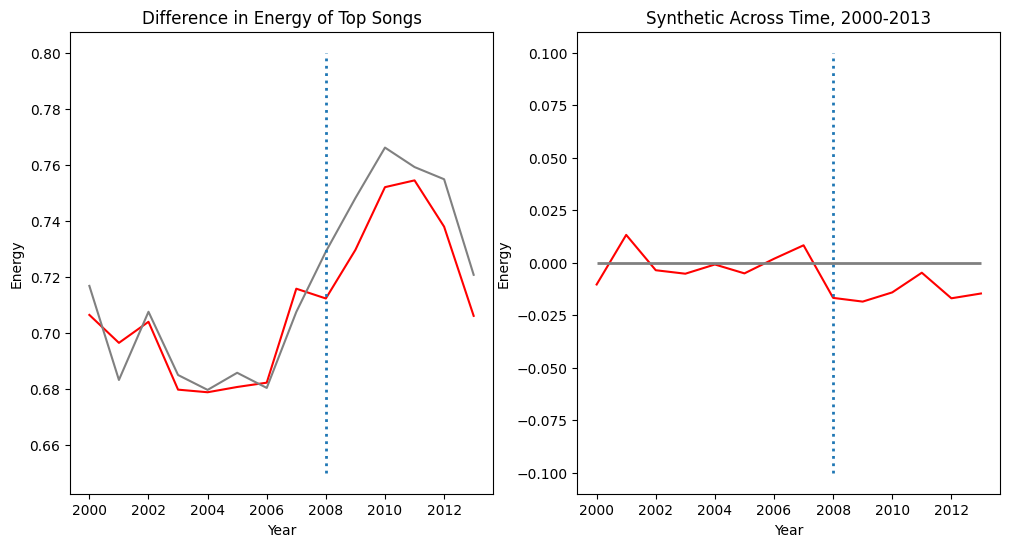

[0.06516571 0.14942313 0.30028589 0.48512527]


In [953]:
print(synthetic_control(2008, 'Energy', chart_panel_df))

<Figure size 1200x600 with 0 Axes>

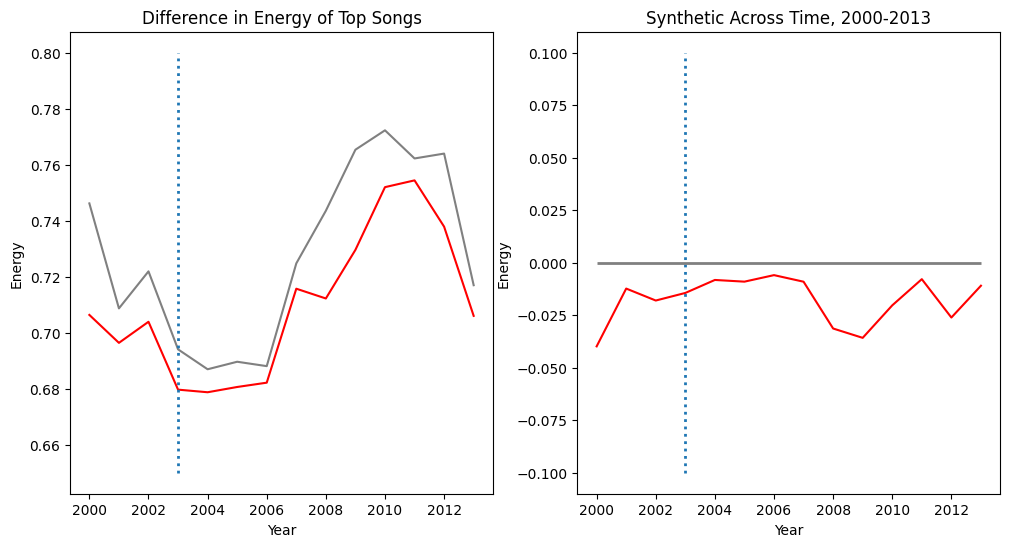

[4.04055217e-01 6.54858112e-17 2.69401542e-01 3.26543242e-01]


In [944]:
# backdating 5 years

print(synthetic_control(2003, 'Energy', chart_panel_df))